# Bot-IoT Network Traffic Classification — LWCE Loss Comparison

PyTorch MLP on Bot-IoT (multi-class: Normal + attack categories).
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [1]:
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Kaggle dataset ID: 'vigneshvenkateswaran/bot-iot'
# 75개 CSV 파일 (공격 유형별 분할), 전체 로드 후 300K 서브샘플링

DATASET_NAME       = 'Bot-IoT'
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
TARGET_TOTAL       = 300_000
BENIGN_MAX         = 100_000
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/Bot-IoT'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/Bot-IoT


In [2]:

def _detect_files(path):
    all_files = sorted(glob.glob(f'{path}/**/*', recursive=True))
    all_files = [f for f in all_files if os.path.isfile(f)]
    print(f'All files found ({len(all_files)}):')
    for f in all_files[:30]:
        print(f'  {os.path.relpath(f, path)}  ({os.path.getsize(f):,} bytes)')
    if len(all_files) > 30:
        print(f'  ... and {len(all_files) - 30} more')
    csv_files     = sorted(glob.glob(f'{path}/**/*.csv',     recursive=True))
    parquet_files = sorted(glob.glob(f'{path}/**/*.parquet', recursive=True))
    return all_files, csv_files, parquet_files


def _detect_label_col(df, priority):
    for c in priority:
        if c in df.columns:
            return c
    col = df.columns[-1]
    print(f'Warning: using last column as label: {col!r}')
    return col


def _stratified_subset(df, label_col, target_total, benign_max):
    unique_labels = df[label_col].unique()
    normal_label  = next((l for l in unique_labels
                          if 'normal' in l.lower() or 'benign' in l.lower()), None)
    non_budget    = target_total - (benign_max if normal_label else 0)
    non_total     = (df[label_col] != normal_label).sum() if normal_label else len(df)
    idx_list = []
    for lbl in unique_labels:
        idx = df.index[df[label_col] == lbl].tolist()
        if normal_label and lbl == normal_label:
            take = min(len(idx), benign_max)
        else:
            prop = len(idx) / max(non_total, 1)
            take = max(50, min(len(idx), int(prop * non_budget)))
        idx_list.extend(np.random.choice(idx, min(take, len(idx)), replace=False).tolist())
    return df.loc[idx_list].reset_index(drop=True)


def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

# Cell 1: Load & Preprocess Bot-IoT
import kagglehub

def load_botiot():
    print('Downloading Bot-IoT...')
    path = kagglehub.dataset_download('vigneshvenkateswaran/bot-iot')
    print(f'Dataset path: {path}')

    all_files, csv_files, _ = _detect_files(path)
    # feature-name 정의 파일 제외
    files = [f for f in csv_files if 'feature' not in os.path.basename(f).lower()]
    if not files:
        files = csv_files
    if not files:
        raise FileNotFoundError(f'No CSV files found. All files: {[os.path.basename(f) for f in all_files]}')

    # 75개 파일 × 1M rows = 75M rows → OOM 방지: 파일당 rows 제한
    rows_per_file = max(5_000, (TARGET_TOTAL * 2) // len(files))
    print(f'\nLoading {len(files)} CSV files, up to {rows_per_file:,} rows each...')
    dfs = []
    for f in files:
        try:
            df_part = pd.read_csv(f, encoding='utf-8', low_memory=False, nrows=rows_per_file)
        except UnicodeDecodeError:
            df_part = pd.read_csv(f, encoding='latin-1', low_memory=False, nrows=rows_per_file)
        dfs.append(df_part)
    df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'Total rows loaded: {len(df):,}')
    print(f'Columns: {df.columns.tolist()}')

    # 'category' 우선 (5-class: Normal, DDoS, DoS, Reconnaissance, Theft)
    LABEL_PRIORITY = ['category', 'Category', 'sub_category',
                      'type', 'Type', 'Attack_type', 'attack_type',
                      'Label', 'label', 'attack', 'Attack']
    label_col = _detect_label_col(df, LABEL_PRIORITY)
    print(f'\nUsing label column: {label_col!r}')
    df['label'] = df[label_col].astype(str).str.strip()
    print(f'Unique labels ({df["label"].nunique()}): {sorted(df["label"].unique())}')

    if set(df['label'].unique()) <= {'0', '1', '0.0', '1.0'}:
        print('Warning: label column appears binary. Consider using category/sub_category.')

    # 숫자 컬럼만 피처로 사용 — 문자열 컬럼(sco, dco, soui, doui 등)은 제외
    feature_cols = [c for c in df.columns if c not in [label_col, 'label']]
    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric features: {len(num_cols)}')

    # inf → NaN 후 0으로 채움
    # (단일 패킷 플로우의 stddev 등은 NaN이 정상 → 0 imputation이 의미적으로 올바름)
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    nan_counts = df[num_cols].isna().sum()
    nan_cols = nan_counts[nan_counts > 0]
    if len(nan_cols) > 0:
        print(f'NaN filled with 0: {nan_cols.to_dict()}')
    df[num_cols] = df[num_cols].fillna(0)

    df_sub = _stratified_subset(df, 'label', TARGET_TOTAL, BENIGN_MAX)
    del df; gc.collect()
    print(f'Subset size: {len(df_sub):,}')

    le = LabelEncoder()
    df_sub['class'] = le.fit_transform(df_sub['label'])
    class_names_enc = le.classes_.tolist()
    num_cls         = len(class_names_enc)
    print(f'Classes ({num_cls}): {class_names_enc}')

    X = df_sub[num_cols].values.astype(np.float32)
    y = df_sub['class'].values.astype(np.int64)

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
    )
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te  = scaler.transform(X_te)

    class_counts = [int((y_tr == i).sum()) for i in range(num_cls)]
    input_dim    = X_tr.shape[1]
    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(class_names_enc, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i:2d} {name:35s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')
    return (X_tr, X_val, X_te, y_tr, y_val, y_te,
            class_counts, input_dim, class_names_enc, num_cls)


(X_tr, X_val, X_te, y_tr, y_val, y_te,
 class_counts, INPUT_DIM, CLASS_NAMES, NUM_CLASSES) = load_botiot()
train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)


100%|██████████| 1.17G/1.17G [00:10<00:00, 114MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/vigneshvenkateswaran/bot-iot/versions/1
All files found (75):
  data_1.csv  (218,326,470 bytes)
  data_10.csv  (203,190,430 bytes)
  data_11.csv  (204,685,380 bytes)
  data_12.csv  (201,327,733 bytes)
  data_13.csv  (205,151,654 bytes)
  data_14.csv  (205,890,955 bytes)
  data_15.csv  (204,550,157 bytes)
  data_16.csv  (205,953,129 bytes)
  data_17.csv  (202,042,320 bytes)
  data_18.csv  (204,848,836 bytes)
  data_19.csv  (204,594,471 bytes)
  data_2.csv  (218,259,016 bytes)
  data_20.csv  (197,784,245 bytes)
  data_21.csv  (206,721,148 bytes)
  data_22.csv  (205,722,416 bytes)
  data_23.csv  (205,628,615 bytes)
  data_24.csv  (205,976,539 bytes)
  data_25.csv  (205,126,466 bytes)
  data_26.csv  (196,826,613 bytes)
  data_27.csv  (207,073,936 bytes)
  data_28.csv  (203,341,040 bytes)
  data_29.csv  (206,760,492 bytes)
  data_3.csv  (204,091,460 bytes)
  data_30.csv  (205,197,386 bytes)
  data_31.csv  (198,948,626 bytes)
  data_32.csv  (206,

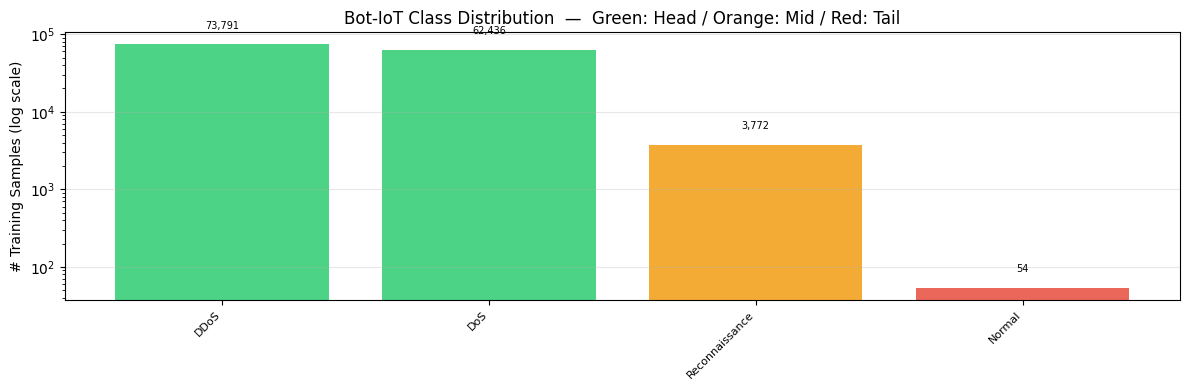

Head (≥61263): 2 classes
Mid  (3735–61263): 1 classes
Tail (<3735): 1 classes


In [3]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]
    fig, ax = plt.subplots(figsize=(max(12, len(class_names)), 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    f'{DATASET_NAME} Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [ ]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    labels = list(range(NUM_CLASSES))
    per_f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]
    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [ ]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    model = build_mlp()
    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )
    history       = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state    = None
    print(f"\n{'='*50}\nTraining {loss_name.upper()} (α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")
    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)
        metrics  = compute_metrics(model, val_loader, class_counts)
        f1_macro = metrics['F1_Macro']
        history['val_F1_Macro'].append(f1_macro)
        scheduler.step(f1_macro)
        if f1_macro > best_F1_Macro:
            best_F1_Macro = f1_macro
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | F1-Macro: {f1_macro:.4f}')
    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [6]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best  = {}
proxy_loader = _make_proxy_loader()

N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (F1-Macro={study_pwce.best_value:.4f})')

N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (F1-Macro={study_plwce.best_value:.4f})')

N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (F1-Macro={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 0.7370 | F1-Macro: 0.0845
✓ PWCE best F1-Macro: 0.3863

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.3301 | F1-Macro: 0.7927
✓ PWCE best F1-Macro: 0.7927

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 0.6805 | F1-Macro: 0.1466
✓ PWCE best F1-Macro: 0.2186

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 0.4702 | F1-Macro: 0.5913
✓ PWCE best F1-Macro: 0.6317

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 0.7173 | F1-Macro: 0.4423
✓ PWCE best F1-Macro: 0.4609

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 0.6943 | F1-Macro: 0.0641
✓ PWCE best F1-Macro: 0.3241

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 1.1011 | F1-Macro: 0.7509
✓ PWCE best F1-Macro: 0.7692

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 0.7477 | F1-Macro: 0.2625
✓ PWCE best F1-Macro: 0.3321

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 0.8207 | F1-Macro: 0.7927
✓ PWCE best F1-Macro

In [7]:
# Cell 6: Full Experiment (N_SEEDS seeds)
import random

N_SEEDS       = 5
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
seed_results   = {ln: [] for ln in LOSS_CONFIGS}
seed_histories = {ln: [] for ln in LOSS_CONFIGS}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} losses × {N_SEEDS} seeds')
print(f"{'='*60}")

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"\n{'─'*25}  Seed {seed}  {'─'*25}")
    for loss_name in LOSS_CONFIGS:
        alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
        gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0
        model, history, _ = train_model(
            loss_name, class_counts, train_loader, val_loader,
            alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
        )
        metrics = compute_metrics(model, test_loader, class_counts)
        seed_results[loss_name].append(metrics)
        seed_histories[loss_name].append(history)
        _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 losses × 5 seeds

─────────────────────────  Seed 0  ─────────────────────────

Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.0028 | F1-Macro: 0.8596
Epoch 20/50 | Loss: 0.0024 | F1-Macro: 0.8663
Epoch 30/50 | Loss: 0.0021 | F1-Macro: 0.8663
Epoch 40/50 | Loss: 0.0017 | F1-Macro: 0.8663
Epoch 50/50 | Loss: 0.0017 | F1-Macro: 0.8663
✓ CE best F1-Macro: 0.8738

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.3143 | F1-Macro: 0.8274
Epoch 20/50 | Loss: 0.2360 | F1-Macro: 0.8309
Epoch 30/50 | Loss: 0.2534 | F1-Macro: 0.8309
Epoch 40/50 | Loss: 0.2461 | F1-Macro: 0.8309
Epoch 50/50 | Loss: 0.2414 | F1-Macro: 0.8274
✓ WCE best F1-Macro: 0.8738

Training PWCE (α=0.50, γ=2.00)
Epoch 10/50 | Loss: 0.0397 | F1-Macro: 0.8596
Epoch 20/50 | Loss: 0.0272 | F1-Macro: 0.8309
Epoch 30/50 | Loss: 0.0203 | F1-Macro: 0.8309
Epoch 40/50 | Loss: 0.0210 | F1-Macro: 0.8211
Epoch 50/50 | Loss: 0.0226 | F1-Macro: 0.8274
✓ PWCE best F1-Macro: 0.8663

Training LWCE (α=1.00


EXPERIMENT SUMMARY (mean ± std, N=5)
Loss                Bal_Acc           F1_Macro            Head_F1            Tail_F1
ce            0.7954±0.0001      0.8250±0.0023      0.9999±0.0000      0.3033±0.0088
wce           0.8772±0.0182      0.9151±0.0167      1.0000±0.0000      0.6635±0.0668
pwce          0.8317±0.0181      0.8682±0.0190      1.0000±0.0000      0.4763±0.0761
lwce          0.8499±0.0369      0.8844±0.0394      1.0000±0.0000      0.5410±0.1577
plwce         0.8454±0.0333      0.8821±0.0317      1.0000±0.0000      0.5317±0.1269
cb            0.8587±0.0338      0.8930±0.0365      0.9995±0.0010      0.5764±0.1443
focal         0.8454±0.0265      0.8836±0.0277      1.0000±0.0000      0.5376±0.1106


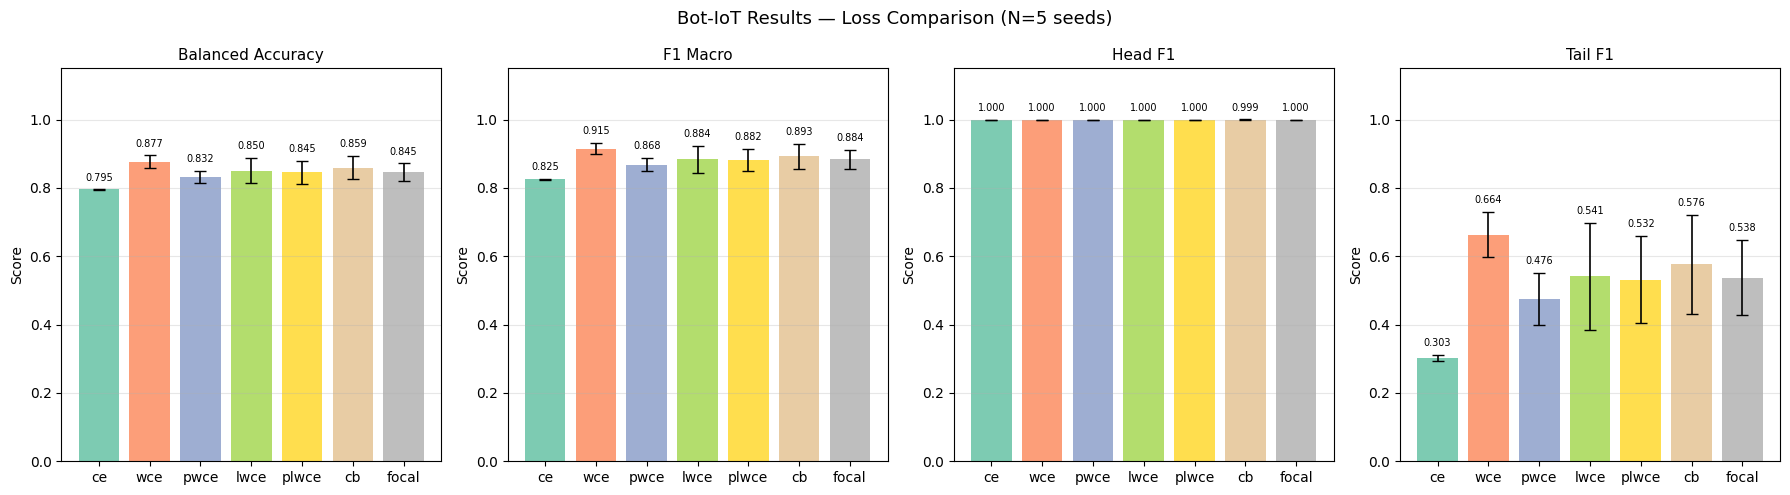

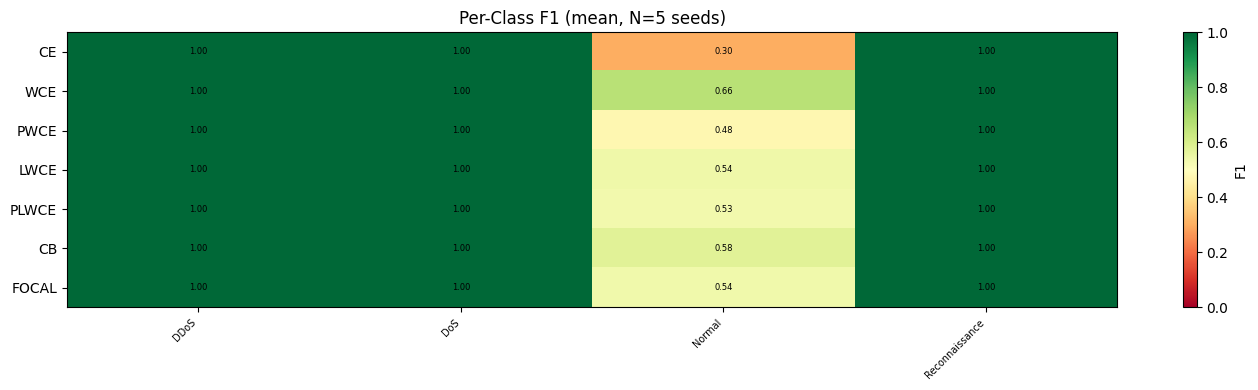

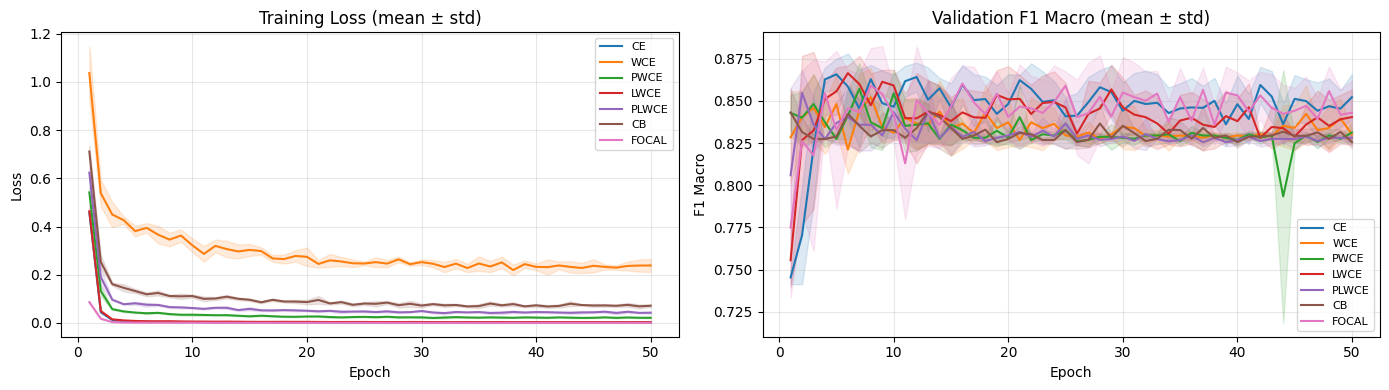

✓ Saved JSON
✓ Saved Excel

FINAL SUMMARY (mean ± std, N=5)
 Loss Balanced_Accuracy      F1_Macro       Head_F1       Tail_F1
   ce     0.7954±0.0001 0.8250±0.0023 0.9999±0.0000 0.3033±0.0088
  wce     0.8772±0.0182 0.9151±0.0167 1.0000±0.0000 0.6635±0.0668
 pwce     0.8317±0.0181 0.8682±0.0190 1.0000±0.0000 0.4763±0.0761
 lwce     0.8499±0.0369 0.8844±0.0394 1.0000±0.0000 0.5410±0.1577
plwce     0.8454±0.0333 0.8821±0.0317 1.0000±0.0000 0.5317±0.1269
   cb     0.8587±0.0338 0.8930±0.0365 0.9995±0.0010 0.5764±0.1443
focal     0.8454±0.0265 0.8836±0.0277 1.0000±0.0000 0.5376±0.1106


In [8]:
# Cell 7: Aggregate + Visualize + Save Results
METRIC_KEYS = ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Mid_F1', 'Tail_F1', 'Accuracy', 'F1_Weighted']
loss_names  = LOSS_CONFIGS

agg = {}
for ln in loss_names:
    agg[ln] = {}
    for k in METRIC_KEYS:
        vals = [r[k] for r in seed_results[ln]]
        agg[ln][k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    per_cls_all = np.array([r['Per_Class_F1'] for r in seed_results[ln]])
    agg[ln]['Per_Class_F1_mean'] = per_cls_all.mean(axis=0).tolist()
    agg[ln]['Per_Class_F1_std']  = per_cls_all.std(axis=0).tolist()

def ms(ln, k): return f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"

print(f"\n{'='*60}\nEXPERIMENT SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
W = 17
print(f"{'Loss':8s}  {'Bal_Acc':>{W}}  {'F1_Macro':>{W}}  {'Head_F1':>{W}}  {'Tail_F1':>{W}}")
for ln in loss_names:
    print(f"{ln:8s}  {ms(ln,'Balanced_Accuracy'):>{W}}  {ms(ln,'F1_Macro'):>{W}}  {ms(ln,'Head_F1'):>{W}}  {ms(ln,'Tail_F1'):>{W}}")

colors = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'{DATASET_NAME} Results — Loss Comparison (N={N_SEEDS} seeds)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1'],
    ['Balanced Accuracy',  'F1 Macro', 'Head F1', 'Tail F1']
):
    means = [agg[ln][key]['mean'] for ln in loss_names]
    stds  = [agg[ln][key]['std']  for ln in loss_names]
    bars  = ax.bar(loss_names, means, color=colors, alpha=0.85)
    ax.errorbar(loss_names, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

per_cls_mat = np.array([agg[ln]['Per_Class_F1_mean'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title(f'Per-Class F1 (mean, N={N_SEEDS} seeds)')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = np.arange(1, FINAL_EPOCHS + 1)
for ln in loss_names:
    loss_arr = np.array([h['train_loss']   for h in seed_histories[ln]])
    f1_arr   = np.array([h['val_F1_Macro'] for h in seed_histories[ln]])
    for ax, arr in zip(axes, [loss_arr, f1_arr]):
        m, s = arr.mean(axis=0), arr.std(axis=0)
        line, = ax.plot(epochs_x, m, label=ln.upper())
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.15, color=line.get_color())
for ax, title, ylabel in zip(axes,
    ['Training Loss (mean ± std)', 'Validation F1 Macro (mean ± std)'],
    ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fname = DATASET_NAME.lower().replace('-', '').replace(' ', '_')
results_json = {
    'metadata': {
        'dataset':      DATASET_NAME,
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'n_seeds':      N_SEEDS,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'aggregated': agg,
    'per_seed':   {ln: seed_results[ln] for ln in loss_names},
}
with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

summary_rows = []
for ln in loss_names:
    row = {'Loss': ln}
    for k in METRIC_KEYS:
        row[f'{k}_mean'] = round(agg[ln][k]['mean'], 4)
        row[f'{k}_std']  = round(agg[ln][k]['std'],  4)
        row[k]           = f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

per_class_df = pd.DataFrame(
    {ln: agg[ln]['Per_Class_F1_mean'] for ln in loss_names},
    index=CLASS_NAMES
)

raw_rows = []
for ln in loss_names:
    for s, r in enumerate(seed_results[ln]):
        row = {'loss': ln, 'seed': s}
        for k in METRIC_KEYS:
            row[k] = r[k]
        raw_rows.append(row)

with pd.ExcelWriter(f'{RESULTS_DIR}/{fname}_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary_MeanStd',  index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1_Mean')
    pd.DataFrame(raw_rows).to_excel(writer, sheet_name='Per_Seed_Raw', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nFINAL SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
disp = ['Loss', 'Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1']
print(summary_df[disp].to_string(index=False))